<a href="https://colab.research.google.com/github/Felipetds/Analise-aluguel-RJ/blob/main/An%C3%A1lise_aluguel_RJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importando os dados





In [52]:
import pandas as pd

In [53]:
url = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'

In [54]:
dados = pd.read_csv(url, sep = ';')

In [55]:
dados.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


#1 - Analisando os dados

In [56]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  object 
 1   Bairro      32960 non-null  object 
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.3+ MB


In [57]:
dados['Tipo'].unique()

array(['Quitinete', 'Casa', 'Conjunto Comercial/Sala', 'Apartamento',
       'Casa de Condomínio', 'Prédio Inteiro', 'Flat', 'Loja/Salão',
       'Galpão/Depósito/Armazém', 'Casa Comercial', 'Casa de Vila',
       'Terreno Padrão', 'Box/Garagem', 'Loft',
       'Loja Shopping/ Ct Comercial', 'Chácara', 'Loteamento/Condomínio',
       'Sítio', 'Pousada/Chalé', 'Studio', 'Hotel', 'Indústria'],
      dtype=object)

In [58]:
dados['Bairro'].unique()

array(['Copacabana', 'Jardim Botânico', 'Barra da Tijuca', 'Centro',
       'Higienópolis', 'Vista Alegre', 'Cachambi', 'Ramos', 'Grajaú',
       'Lins de Vasconcelos', 'Botafogo', 'Taquara',
       'Freguesia (Jacarepaguá)', 'Tijuca', 'Olaria', 'Leblon',
       'São Cristóvão', 'Ipanema', 'Campo Grande',
       'Recreio dos Bandeirantes', 'Jardim Oceânico', 'Humaitá',
       'Península', 'Méier', 'Vargem Pequena', 'Maracanã', 'Jacarepaguá',
       'Vargem Grande', 'São Conrado', 'Maria da Graça', 'Vila Valqueire',
       'Gávea', 'Cosme Velho', 'Bonsucesso', 'Todos os Santos',
       'Laranjeiras', 'Itanhangá', 'Flamengo', 'Praça Seca', 'Piedade',
       'Lagoa', 'Santo Cristo', 'Largo do Machado', 'Catete',
       'Jardim Carioca', 'Benfica', 'Glória', 'Vila Isabel',
       'Quintino Bocaiúva', 'São Francisco Xavier', 'Rocha Miranda',
       'Engenho Novo', 'Engenho de Dentro', 'Cidade Nova', 'Pilares',
       'Arpoador', 'Tomás Coelho', 'Água Santa', 'Ilha do Governador',
       'Ja

#2 - Calculando a média por tipo

In [59]:
dados['Valor'].mean()

np.float64(12952.659715265761)

In [60]:
#dados.groupby('Tipo').mean(numeric_only=True) - Seleciona somente as colunas de valor numerico para realizar o calculo da média

media_valor_tipo = dados.groupby('Tipo')['Valor'].mean().sort_values(ascending=True)

<Axes: ylabel='Tipo'>

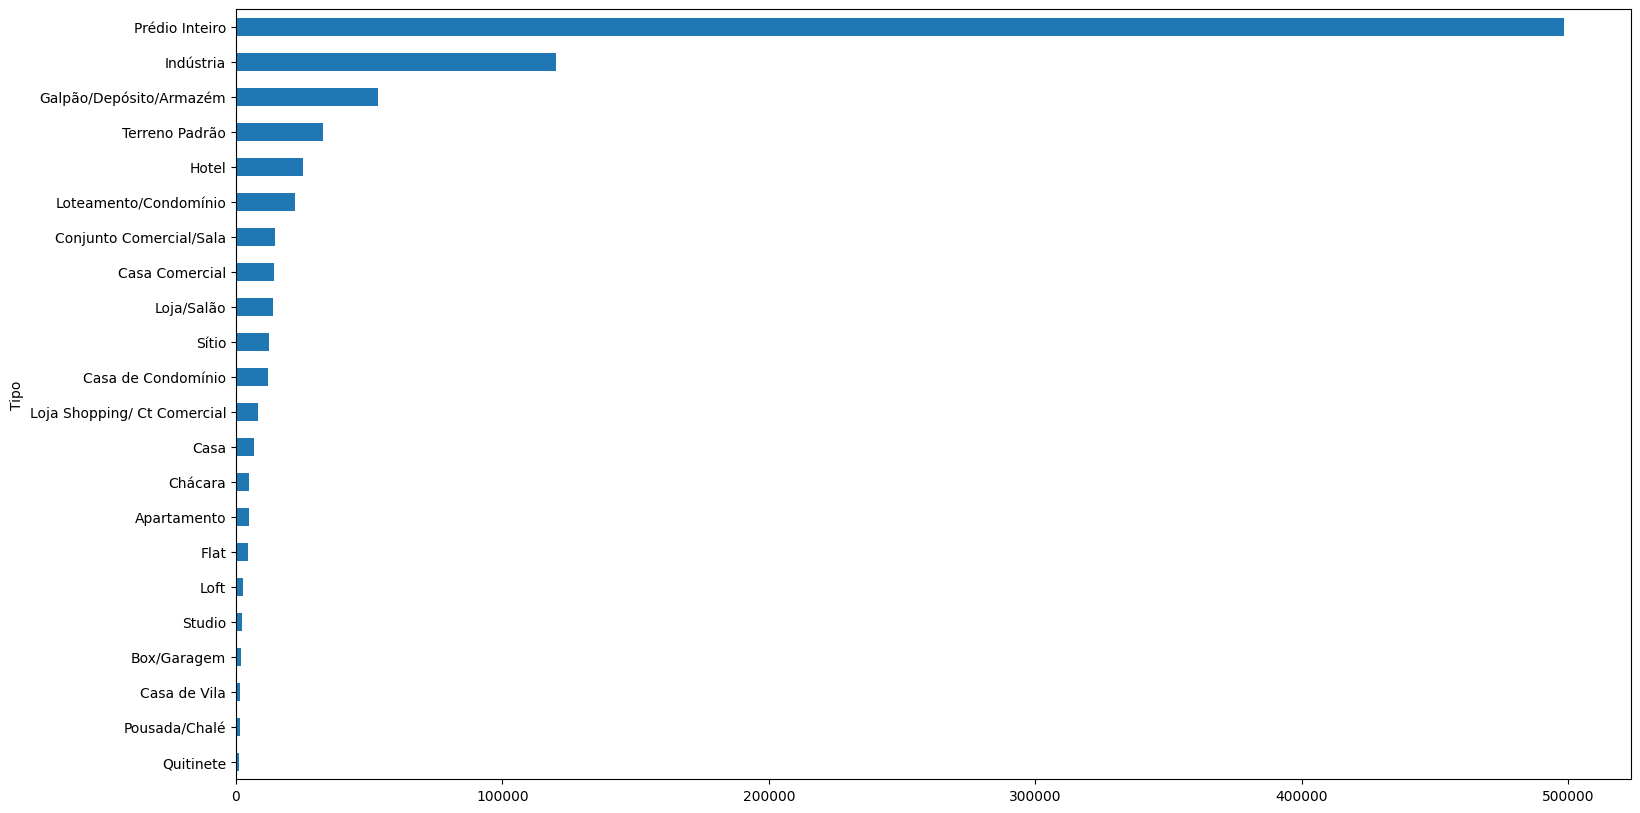

In [61]:
media_valor_tipo.plot(kind='barh', figsize=(18, 10))

#3 - Separando Comerciais de Residenciais

In [62]:
imoveis_comerciais = ['Conjunto Comercial/Sala',
                      'Prédio Inteiro', 'Loja/Salão',
                      'Galpão/Depósito/Armazém',
                      'Casa Comercial', 'Terreno Padrão',
                      'Loja Shopping/ Ct Comercial',
                      'Box/Garagem', 'Chácara',
                      'Loteamento/Condomínio', 'Sítio',
                      'Pousada/Chalé', 'Hotel', 'Indústria']

In [63]:
dados_residencia = dados.query('@imoveis_comerciais not in Tipo')

In [64]:
dados_residencia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23111 entries, 0 to 32958
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        23111 non-null  object 
 1   Bairro      23111 non-null  object 
 2   Quartos     23111 non-null  int64  
 3   Vagas       23111 non-null  int64  
 4   Suites      23111 non-null  int64  
 5   Area        23111 non-null  int64  
 6   Valor       23102 non-null  float64
 7   Condominio  21246 non-null  float64
 8   IPTU        16232 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 1.8+ MB


#4 - Quantidade de residencias por tipo

In [65]:
media_valor_tipo_residencial = dados_residencia.groupby('Tipo')['Valor'].mean().sort_values(ascending=True)

<Axes: ylabel='Tipo'>

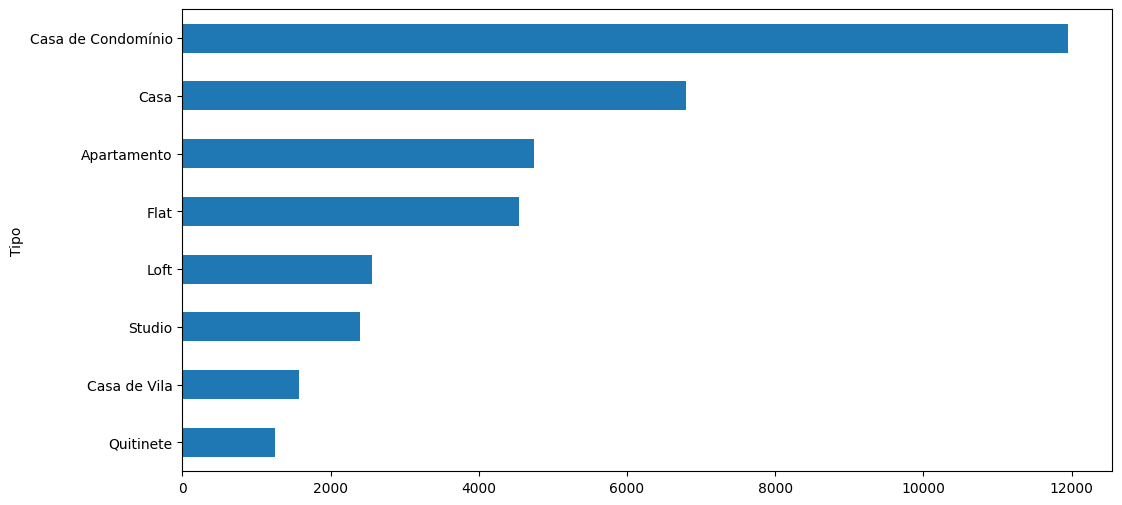

In [66]:
media_valor_tipo_residencial.plot(kind='barh', figsize=(12, 6))

In [67]:
dados_residencia['Tipo'].value_counts()

,count
Tipo,
Apartamento,19532
Casa de Condomínio,996
Casa,967
Quitinete,836
Flat,476
Casa de Vila,249
Loft,51
Studio,4


In [68]:
porcentagem_tipo_residencial = dados_residencia.Tipo.value_counts(normalize=True).to_frame().sort_values('Tipo')

<Axes: ylabel='Tipo'>

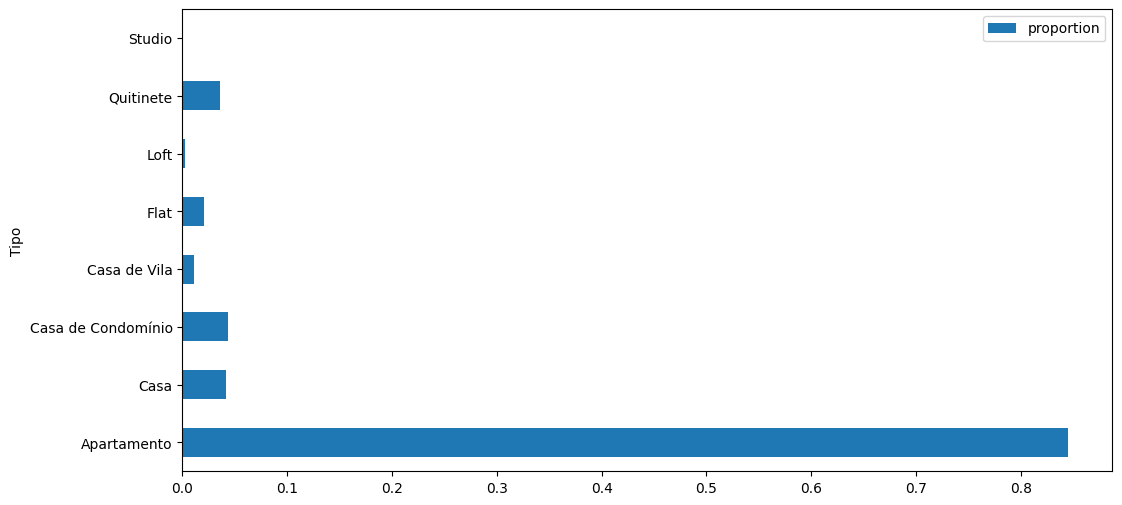

In [69]:
porcentagem_tipo_residencial.plot(kind='barh', figsize=(12, 6))

In [70]:
dados_apartamentos = dados_residencia.query('Tipo == "Apartamento"')

In [71]:
dados_apartamentos.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN


In [72]:
dados_apartamentos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19532 entries, 3 to 32958
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        19532 non-null  object 
 1   Bairro      19532 non-null  object 
 2   Quartos     19532 non-null  int64  
 3   Vagas       19532 non-null  int64  
 4   Suites      19532 non-null  int64  
 5   Area        19532 non-null  int64  
 6   Valor       19525 non-null  float64
 7   Condominio  18787 non-null  float64
 8   IPTU        14060 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 1.5+ MB


#5 - Extraindo mais algumas informações

O time de ML chegou com algumas demandas de última hora para resolvermos nesse momento da análise exploratória. Essas demandas são:

1) Calcular a média de quartos dos imóveis;

2) Conferir quantos bairros únicos existem na nossa base de dados;

3) Analisar quais bairros possuem a média de valor de aluguel mais elevadas;

4) Criar um gráfico de barras horizontais que apresente os 5 bairros com as médias de valores de aluguel mais elevadas.

In [74]:
dados_residencia.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN


In [75]:
dados_residencia.groupby('Tipo')['Quartos'].mean()

,Quartos
Tipo,
Apartamento,2.481569
Casa,3.133402
Casa de Condomínio,4.007028
Casa de Vila,1.927711
Flat,1.415966
Loft,1.117647
Quitinete,0.834928
Studio,0.500000


In [77]:
dados_residencia.Bairro.nunique()

154

In [79]:
dados_residencia.groupby('Bairro')['Valor'].mean().sort_values(ascending=False)

,Valor
Bairro,
Joá,16773.478261
Cidade Jardim,12000.000000
Arpoador,10896.062500
Paquetá,10550.000000
Ipanema,9196.116863
...,...
Honório Gurgel,655.555556
Senador Camará,600.000000
Paciência,580.000000


<Axes: xlabel='Bairro'>

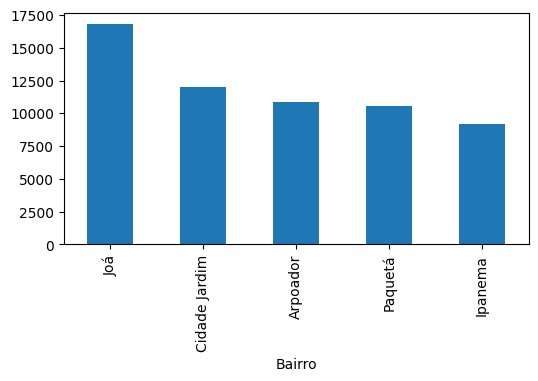

In [85]:
media_aluguel_bairro = dados_residencia.groupby('Bairro')['Valor'].mean().sort_values(ascending=False)
media_aluguel_bairro = media_aluguel_bairro.head(5)
media_aluguel_bairro.plot(kind='bar', figsize=(6, 3), )

#6 - Dados nulos